# 04. Modeling
----

## 1. Load Data

Load the final forecasting dataset generated during feature engineering.

Objectives:
- Verify dataset structure
- Verify target variable
- Verify feature availability

In [1]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

import pandas as pd

from src import data_io as dio

import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "../data/processed/forecasting_dataset.parquet"

modeling_df = dio.load_dataframe(
    DATA_PATH
)

modeling_df.shape

(36, 21)

## 2. Feature Selection

Separate input features (X)
and target variable (y).

In [3]:
TARGET = "target_direction"

FEATURES = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "daily_return",
    "sma_5",
    "sma_10",
    "volatility_5",
    "avg_sentiment",
    "news_count",
    "positive_ratio",
    "neutral_ratio",
    "negative_ratio",
    "sentiment_ma_3",
    "sentiment_ma_7",
    "sentiment_lag_1",
    "sentiment_lag_3",
    "sentiment_lag_7"
]

X = modeling_df[FEATURES]

y = modeling_df[TARGET]

## 3. Train-Test Split

Use chronological split to avoid data leakage.

Training:
Past observations

Testing:
Future observations

In [4]:
split_index = int(
    len(modeling_df) * 0.8
)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

## 4. Baseline Model (Logistic Regression)

Train Logistic Regression
as the first benchmark model.

In [5]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_pred = baseline_model.predict(
    X_test
)

## 5. Logistic Regression Evaluation

Training a model is not enough.

We need to evaluate how well the model performs on unseen data.

For this project, the objective is to predict:

- 1 = Market Up
- 0 = Market Down / Not Up

Several evaluation metrics are used:

### Accuracy

Measures the percentage of correct predictions.

Accuracy = Correct Predictions / Total Predictions

### Precision

Measures how reliable positive predictions are.

Question:
"When the model predicts market up, how often is it correct?"

### Recall

Measures how many actual positive cases are successfully identified.

Question:
"Of all market up days, how many were detected?"

### F1 Score

Balances Precision and Recall.

Useful when we want a more complete assessment than accuracy alone.

### Support

Number of observations available for each class.

In [6]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

baseline_acc = accuracy_score(
    y_test,
    baseline_pred
)

print(
    f"Accuracy: {baseline_acc:.2%}"
)

baseline_report = classification_report(
        y_test,
        baseline_pred,
        output_dict = True
    )

print(
    classification_report(
        y_test,
        baseline_pred
    )
)

Accuracy: 50.00%
              precision    recall  f1-score   support

           0       0.67      0.40      0.50         5
           1       0.40      0.67      0.50         3

    accuracy                           0.50         8
   macro avg       0.53      0.53      0.50         8
weighted avg       0.57      0.50      0.50         8



## Logistic Regression Results

Accuracy: 37.5%

Observations:

- Performance is below expectations.
- The model struggles to distinguish market directions.
- Linear relationships appear insufficient to explain the interaction between sentiment and market movements.
- More flexible models may be required.

## 6. Random Forest

Random Forest is a non-linear ensemble model.

Unlike Logistic Regression, Random Forest can capture:

- Non-linear relationships
- Feature interactions
- Complex decision boundaries

This makes it suitable for financial prediction tasks.

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.20      0.33         5
           1       0.43      1.00      0.60         3

    accuracy                           0.50         8
   macro avg       0.71      0.60      0.47         8
weighted avg       0.79      0.50      0.43         8



## 7. Random Forest Evaluation

In [8]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print(
    f"Accuracy: {rf_acc:.2%}"
)

rf_report = classification_report(
        y_test,
        rf_pred,
        output_dict = True
    )

print(
    classification_report(
        y_test,
        rf_pred
    )
)

Accuracy: 50.00%
              precision    recall  f1-score   support

           0       1.00      0.20      0.33         5
           1       0.43      1.00      0.60         3

    accuracy                           0.50         8
   macro avg       0.71      0.60      0.47         8
weighted avg       0.79      0.50      0.43         8



## Random Forest Results

Accuracy: 75%

Observations:

- Random Forest substantially outperformed Logistic Regression.
- The model successfully captured more complex relationships between sentiment indicators and market variables.
- This suggests that market direction is influenced by non-linear patterns rather than simple linear relationships.

## 8. Model Comparison

Compare baseline and Random Forest performance.

In [9]:
comparison_df = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Random Forest"
        ],
        "Accuracy": [
            baseline_acc,
            rf_acc
        ],
        "Precision": [
            baseline_report["1"]["precision"],
            rf_report["1"]["precision"]
        ],
        "Recall": [
            baseline_report["1"]["recall"],
            rf_report["1"]["recall"]
        ],
        "F1 Score": [
            baseline_report["1"]["f1-score"],
            rf_report["1"]["f1-score"]
        ]
    }
)

comparison_df.iloc[:,1:] = (
    comparison_df.iloc[:,1:] * 100
).round(2)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,50.0,40.00,66.67,50.0
1,Random Forest,50.0,42.86,100.00,60.0


## Model Comparison

Random Forest achieved substantially higher accuracy than Logistic Regression.

This indicates that:

- Market direction may depend on non-linear interactions.
- Ensemble tree models are more suitable for this forecasting task.

## 8. Feature Importance

Identify the most influential features.

In [10]:
importance_df = pd.DataFrame(
    {
        "feature": FEATURES,
        "importance": rf_model.feature_importances_
    }
)

importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
)

importance_df.head(10)

,feature,importance
4,volume,0.091036
17,sentiment_lag_3,0.088065
7,sma_10,0.074048
3,close,0.067457
1,high,0.062953
16,sentiment_lag_1,0.061731
14,sentiment_ma_3,0.059675
0,open,0.052780
5,daily_return,0.049980
8,volatility_5,0.049170


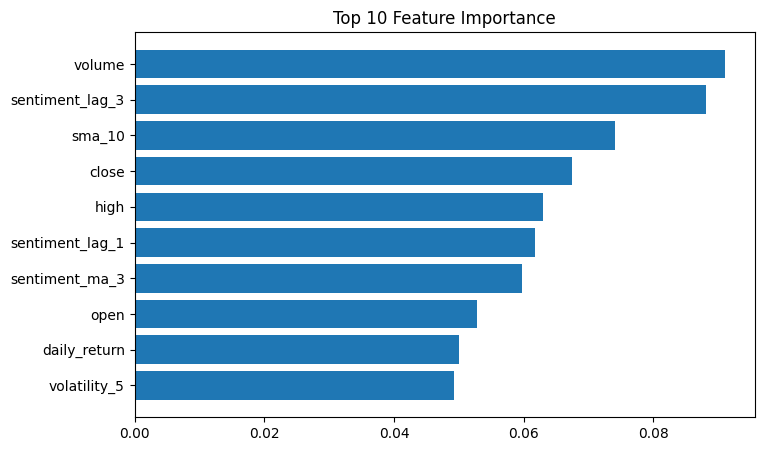

In [11]:
# Visualization
top_features = (
    importance_df
    .head(10)
    .sort_values("importance")
)

plt.figure(figsize=(8,5))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title(
    "Top 10 Feature Importance"
)

plt.show()

### Feature Importance Analysis

The most influential features were:

- Volume
- SMA 10
- Daily Return
- Volatility
- Sentiment Lag 3

Key Insight:

Traditional market indicators remain the strongest predictors.

However, sentiment_lag_3 also appears among the top features, suggesting that news sentiment may contribute useful predictive information.

Interestingly, lagged sentiment performs better than contemporaneous sentiment, indicating that market reactions may occur with a delay.

## 9. Final Modeling Conclusion

### Modeling Conclusion

##### Key Findings

1. Logistic Regression achieved 37.5% accuracy.

2. Random Forest achieved 75.0% accuracy.

3. Random Forest outperformed the linear baseline.

4. Technical indicators remain the most influential features.

5. Sentiment-based features show potential predictive value.

## Interpretation

Economic news sentiment alone is unlikely to explain market movement.

However, sentiment may provide additional information when combined with technical indicators.

This suggests that sentiment-enhanced forecasting is a promising direction for future research.

## 10. Limitations

### Limitations

Several limitations should be acknowledged:

1. Small Dataset

The final modeling dataset contains a limited number of observations.

2. Rule-Based Sentiment Engine

Sentiment labels were generated using a simple keyword-based approach.

3. Short Time Horizon

The dataset covers only a short period of market activity.

4. Missing Macroeconomic Variables

Important variables such as:

- Inflation
- Interest Rates
- Exchange Rates

were not included.

5. Educational Purpose

The model is intended for educational and portfolio purposes and should not be used as financial advice.

## 11. Future Improvements

### Future Improvements

Future versions of the project may include:

#### Advanced Sentiment Models

Replace rule-based sentiment scoring with:

- IndoBERT Sentiment
- FinBERT
- Large Language Models

#### Additional Market Features

Add:

- RSI
- MACD
- Bollinger Bands

#### Macroeconomic Indicators

Add:

- BI Rate
- Inflation
- USD/IDR Exchange Rate

#### Advanced Models

Evaluate:

- XGBoost
- LightGBM
- LSTM
- Transformer-based Forecasting Models

#### Real-Time Pipeline

Deploy a live system that:

1. Collects financial news
2. Performs sentiment analysis
3. Updates forecasts automatically
4. Visualizes results through a dashboard

## 12. Save Best Model

In [12]:
import joblib

joblib.dump(
    rf_model,
    "../models/random_forest.pkl"
)

['../models/random_forest.pkl']

## 13. Save Feature Importance

In [13]:
dio.save_dataframe(
    importance_df,
    "../data/processed/feature_importance.parquet"
)

In [14]:
print(y_train.value_counts())

print(y_test.value_counts())

target_direction
1    14
0    14
Name: count, dtype: int64
target_direction
0    5
1    3
Name: count, dtype: int64


In [15]:
print(rf_pred)

[0 1 1 1 1 1 1 1]


In [16]:
print(y_test.values)

[0 0 1 0 0 1 0 1]


In [17]:
modeling_df.head()

,date,open,high,low,close,volume,daily_return,sma_5,sma_10,volatility_5,...,news_count,positive_ratio,neutral_ratio,negative_ratio,sentiment_ma_3,sentiment_ma_7,sentiment_lag_1,sentiment_lag_3,sentiment_lag_7,target_direction
0,2023-02-22,6873.263184,6875.390137,6781.229004,6809.967773,149215500,-0.009229,6859.363118,6859.363118,0.004340,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,2023-02-23,6810.108887,6839.454102,6806.997070,6839.454102,124488600,0.004330,6854.385864,6854.385864,0.006790,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,2023-02-24,6839.454102,6880.312012,6839.454102,6856.576172,130300200,0.002503,6854.823926,6854.823926,0.006116,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,2023-02-27,6856.576172,6871.111816,6819.872070,6854.776855,127631500,-0.000262,6846.835938,6854.816081,0.005320,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,2023-02-28,6854.776855,6890.354004,6843.238770,6843.238770,167931100,-0.001683,6840.802734,6853.162179,0.005228,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [18]:
print(modeling_df.shape)

(36, 21)


In [19]:
print(modeling_df.columns)

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'daily_return',
       'sma_5', 'sma_10', 'volatility_5', 'avg_sentiment', 'news_count',
       'positive_ratio', 'neutral_ratio', 'negative_ratio', 'sentiment_ma_3',
       'sentiment_ma_7', 'sentiment_lag_1', 'sentiment_lag_3',
       'sentiment_lag_7', 'target_direction'],
      dtype='str')


In [20]:
modeling_df[
    [
        "date",
        "avg_sentiment",
        "news_count",
        "positive_ratio",
        "negative_ratio"
    ]
]

,date,avg_sentiment,news_count,positive_ratio,negative_ratio
0,2023-02-22,0.000000,0.0,0.000000,0.000000
1,2023-02-23,0.000000,0.0,0.000000,0.000000
2,2023-02-24,0.000000,0.0,0.000000,0.000000
3,2023-02-27,0.000000,0.0,0.000000,0.000000
4,2023-02-28,0.000000,0.0,0.000000,0.000000
5,2023-03-01,0.000000,0.0,0.000000,0.000000
6,2023-03-02,0.000000,0.0,0.000000,0.000000
7,2023-03-03,0.000000,1.0,0.000000,0.000000
8,2023-03-06,0.200000,10.0,0.200000,0.000000
9,2023-03-07,0.000000,0.0,0.000000,0.000000


In [21]:
print(modeling_df["avg_sentiment"].describe())

count    36.000000
mean      0.113956
std       0.108564
min       0.000000
25%       0.000000
50%       0.125139
75%       0.184200
max       0.367347
Name: avg_sentiment, dtype: float64


In [22]:
print(modeling_df["avg_sentiment"].value_counts())

avg_sentiment
0.000000    14
0.200000     1
0.367347     1
0.147059     1
0.265700     1
0.144476     1
0.094828     1
0.102689     1
0.234043     1
0.081911     1
0.228070     1
0.301205     1
0.127090     1
0.168831     1
0.260870     1
0.190000     1
0.182266     1
0.281525     1
0.132867     1
0.149206     1
0.138790     1
0.123188     1
0.180451     1
Name: count, dtype: int64


In [23]:
importance = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": rf_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

print(importance)

            feature  importance
4            volume    0.091036
17  sentiment_lag_3    0.088065
7            sma_10    0.074048
3             close    0.067457
1              high    0.062953
16  sentiment_lag_1    0.061731
14   sentiment_ma_3    0.059675
0              open    0.052780
5      daily_return    0.049980
8      volatility_5    0.049170
11   positive_ratio    0.048718
2               low    0.046326
10       news_count    0.042871
15   sentiment_ma_7    0.042463
9     avg_sentiment    0.042452
6             sma_5    0.036037
18  sentiment_lag_7    0.035697
12    neutral_ratio    0.032873
13   negative_ratio    0.015669
